# Step 5 — Value of weather information by prediction horizon (main experiment)

Trains LightGBM under the oracle and deployable settings (`H0`, `H2`, `H6`) with four weather configurations per setting, and decomposes the weather gain between origin and destination (paper Sect. 5.1–5.2, Tables 5–6, Fig. 4).

- **Input:** `data/processed/flights_clean.parquet`, `data/processed/wx_*.parquet`
- **Output:** `results/results_horizon.csv`, `results/results_horizon_shapley.csv`

Protocol: chronological split (train 2018–2021, validation Jan–Apr 2022, test May–Jul 2022); out-of-fold target encoding; three seeds; paired day-level block bootstrap for confidence intervals.

### Setup and configuration
All experiment parameters are defined here (`SAMPLE <= 1` subsamples the training set for a quick test run).
Use 0.1 for a quick test

In [ ]:
import time, gc, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import (mean_absolute_error, mean_squared_errojr, r2_score, roc_auc_score,
                             average_precision_score, precision_recall_curve, f1_score)
from sklearn.model_selection import KFold

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'README.md').exists())  # project root
warnings.filterwarnings('ignore')

DATA = ROOT / 'data' / 'processed'
RESULTS = ROOT / 'results'; RESULTS.mkdir(parents=True, exist_ok=True)
SETTINGS = ['oracle', 'H0', 'H2', 'H6']      # weather feature sets built in flights.ipynb
CONFIGS  = ['none', 'org', 'dst', 'both']    # four-cell ablation
SEEDS    = [42, 43, 44]
SAMPLE   = 0.1                               # use 0.1 for a quick test run
N_BOOT   = 1000                              # bootstrap resamples
REG_OBJECTIVE = 'regression'                 # alternatives: 'huber', 'regression_l1'
TRAIN_END, VAL_END = '2022-01-01', '2022-05-01'

### Load data and chronological split

In [2]:
BASE_NUM = ['Month', 'DayOfWeek', 'CRSDepHour', 'CRSArrHour', 'CRSElapsedTime', 'Distance',
            'DistanceGroup', 'DepHour_sin', 'DepHour_cos', 'Month_sin', 'Month_cos',
            'DoW_sin', 'DoW_cos', 'IsWeekend', 'IsPeakHour', 'IsHoliday']
HIGH_CARD = ['Origin', 'Dest', 'Airline', 'Tail_Number']
LOW_CARD  = ['OriginState', 'DestState', 'DepTimeBlk']

df = pd.read_parquet(DATA / 'flights_clean.parquet',
                     columns=['row_id', 'FlightDate', 'ArrDelayMinutes', 'ArrDel15'] + BASE_NUM + HIGH_CARD + LOW_CARD)
assert (df['row_id'].values == np.arange(len(df))).all()

tr = (df['FlightDate'] < TRAIN_END).values
va = ((df['FlightDate'] >= TRAIN_END) & (df['FlightDate'] < VAL_END)).values
te = (df['FlightDate'] >= VAL_END).values
if SAMPLE < 1.0:
    tr = tr & (np.random.RandomState(0).rand(len(df)) < SAMPLE)
print(f'Train {tr.sum():,} | Val {va.sum():,} | Test {te.sum():,}')

Train 855,049 | Val 792,335 | Test 638,672


### Targets and out-of-fold target encoding
- Targets: `ArrDelayMinutes` (regression, capped at the training 99.9th percentile) and `ArrDel15` (classification).
- High-cardinality identifiers (origin, destination, airline, tail number) are target-encoded with 5-fold **out-of-fold** statistics on the training set, so that a row's encoding never contains its own label; validation and test use full-training statistics. Smoothing: `(sum + m·prior) / (count + m)`, `m = 10`.

In [3]:
y_reg = df['ArrDelayMinutes'].astype('float32').values
cap = np.quantile(y_reg[tr], 0.999)
y_reg = np.minimum(y_reg, cap)
y_cls = df['ArrDel15'].astype('int8').values
print(f'Target capped at {cap:.0f} min')


def target_encode_oof(col, y, m=10.0, n_folds=5, seed=0):
    prior = y[tr].mean()
    out = np.full(len(col), np.nan, dtype='float32')
    vals = col.values

    def fit_apply(fit_idx, apply_idx):
        s = pd.DataFrame({'k': vals[fit_idx], 'y': y[fit_idx]}).groupby('k')['y'].agg(['sum', 'count'])
        enc = (s['sum'] + m * prior) / (s['count'] + m)
        out[apply_idx] = pd.Series(vals[apply_idx]).map(enc).fillna(prior).values

    tr_idx = np.where(tr)[0]
    for f_idx, a_idx in KFold(n_folds, shuffle=True, random_state=seed).split(tr_idx):
        fit_apply(tr_idx[f_idx], tr_idx[a_idx])          # train: out-of-fold
    fit_apply(tr_idx, np.where(~tr)[0])                  # val/test: full-training statistics
    return out


X_base = df[BASE_NUM].astype('float32').copy()
for c in HIGH_CARD:
    X_base[f'{c}_te'] = target_encode_oof(df[c].astype(str), y_cls.astype('float32'))
for c in LOW_CARD:
    X_base[c] = df[c].astype('category')                 # native LightGBM categorical
dates_test = df.loc[te, 'FlightDate'].values
print('X_base:', X_base.shape)

Target capped at 538 min
X_base: (9981331, 23)


### Constant baselines
Always 0 (= median), median, and training mean. Because about two thirds of targets are zero, the MAE-optimal constant is zero.

In [4]:
rows = []
for name, const in [('const_zero', 0.0), ('const_median', float(np.median(y_reg[tr]))),
                    ('const_mean', float(y_reg[tr].mean()))]:
    p = np.full(te.sum(), const, dtype='float32')
    rows.append(dict(setting='-', config=name, seed=-1, MAE=mean_absolute_error(y_reg[te], p),
                     RMSE=np.sqrt(mean_squared_error(y_reg[te], p)), R2=r2_score(y_reg[te], p)))
    print(f'{name:13s}  const={const:6.2f}  MAE={rows[-1]["MAE"]:.3f}  R2={rows[-1]["R2"]:+.4f}')
print(f'\nMean test target = {y_reg[te].mean():.2f} min (= MAE of the constant-zero predictor)')

const_zero     const=  0.00  MAE=16.426  R2=-0.1368
const_median   const=  0.00  MAE=16.426  R2=-0.1368
const_mean     const= 12.10  MAE=20.768  R2=-0.0095

Mean test target = 16.43 min (= MAE of the constant-zero predictor)


### LightGBM training and evaluation
Early stopping on validation; the classification threshold maximising F1 is tuned on validation and applied to test.

In [5]:
def lgb_params(seed, task):
    p = dict(learning_rate=0.05, num_leaves=255, min_data_in_leaf=200, feature_fraction=0.8,
             bagging_fraction=0.8, bagging_freq=5, lambda_l2=1.0, verbose=-1, seed=seed,
             num_threads=-1, max_cat_to_onehot=16)
    if task == 'reg':
        p.update(objective=REG_OBJECTIVE, metric='l1')
        if REG_OBJECTIVE == 'huber':
            p['alpha'] = 30.0
    else:
        p.update(objective='binary', metric='binary_logloss')
    return p


def fit_predict(X, seed):
    out = {}
    for task, y in [('reg', y_reg), ('cls', y_cls)]:
        dtr = lgb.Dataset(X[tr], label=y[tr])
        dva = lgb.Dataset(X[va], label=y[va], reference=dtr)
        m = lgb.train(lgb_params(seed, task), dtr, num_boost_round=3000, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(100, verbose=False)])
        out[task] = dict(val=m.predict(X[va], num_iteration=m.best_iteration),
                         test=m.predict(X[te], num_iteration=m.best_iteration),
                         iters=m.best_iteration, model=m)
    return out


def evaluate(pred):
    pr, pc = pred['reg']['test'], pred['cls']['test']
    prec, rec, thr = precision_recall_curve(y_cls[va], pred['cls']['val'])
    f1v = 2 * prec * rec / (prec + rec + 1e-9)
    thr_star = thr[np.argmax(f1v[:-1])]
    return dict(MAE=mean_absolute_error(y_reg[te], pr), RMSE=np.sqrt(mean_squared_error(y_reg[te], pr)),
                R2=r2_score(y_reg[te], pr), AUC=roc_auc_score(y_cls[te], pc),
                PR_AUC=average_precision_score(y_cls[te], pc), F1=f1_score(y_cls[te], pc > thr_star),
                thr=thr_star, iters_reg=pred['reg']['iters'], iters_cls=pred['cls']['iters'])

### Day-level block bootstrap
Flights on the same day share weather and congestion, so absolute errors (and Brier scores) are aggregated by day and test days are resampled with replacement (1,000 times) to obtain 95% confidence intervals of paired differences.

In [6]:
def per_day(pred):
    ae = np.abs(y_reg[te] - pred['reg']['test'])
    br = (pred['cls']['test'] - y_cls[te]) ** 2
    return pd.DataFrame({'d': dates_test, 'ae': ae, 'br': br}).groupby('d').agg(['sum', 'count'])


def boot_ci(day_a, day_b, n_boot=N_BOOT, seed=0):
    idx = np.random.RandomState(seed).randint(0, len(day_a), size=(n_boot, len(day_a)))
    res = {}
    for k in ['ae', 'br']:
        sa, sb, c = day_a[(k, 'sum')].values, day_b[(k, 'sum')].values, day_a[(k, 'count')].values
        d = (sa[idx].sum(1) - sb[idx].sum(1)) / c[idx].sum(1)
        res[k] = (np.percentile(d, 2.5), np.percentile(d, 97.5))
    return res

### Experiment grid
4 settings × 4 configurations (`none`, `org`, `dst`, `both`) per seed; `none` does not depend on the setting and is trained once per seed.

In [7]:
day_cache, models_kept = {}, {}
for seed in SEEDS:
    t = time.time()
    pred = fit_predict(X_base, seed)
    r = evaluate(pred)
    rows.append(dict(setting='-', config='none', seed=seed, **r))
    day_cache[('none', seed)] = per_day(pred)
    print(f'[seed {seed}] none         MAE={r["MAE"]:.3f} R2={r["R2"]:+.4f} AUC={r["AUC"]:.4f} ({time.time()-t:.0f}s)')

    for setting in SETTINGS:
        W = pd.read_parquet(DATA / f'wx_{setting}.parquet')
        assert (W['row_id'].values == np.arange(len(W))).all(), 'row order mismatch'
        org_cols = [c for c in W.columns if c.startswith('org_')]
        dst_cols = [c for c in W.columns if c.startswith('dst_')]
        for config in [c for c in CONFIGS if c != 'none']:
            use = {'org': org_cols, 'dst': dst_cols, 'both': org_cols + dst_cols}[config]
            X = pd.concat([X_base, W[use].astype('float32')], axis=1)
            t = time.time()
            pred = fit_predict(X, seed)
            r = evaluate(pred)
            ci = boot_ci(per_day(pred), day_cache[('none', seed)])
            r.update(dMAE_lo=ci['ae'][0], dMAE_hi=ci['ae'][1], dBrier_lo=ci['br'][0], dBrier_hi=ci['br'][1])
            rows.append(dict(setting=setting, config=config, seed=seed, **r))
            if config == 'both' and seed == SEEDS[0]:
                models_kept[setting] = (pred['reg']['model'], use)
            print(f'[seed {seed}] {setting:6s} {config:4s}  MAE={r["MAE"]:.3f} R2={r["R2"]:+.4f} '
                  f'AUC={r["AUC"]:.4f}  ΔMAE CI=[{r["dMAE_lo"]:+.3f}, {r["dMAE_hi"]:+.3f}] ({time.time()-t:.0f}s)')
            del X; gc.collect()
        del W; gc.collect()

res = pd.DataFrame(rows)
res.to_csv(RESULTS / 'results_horizon.csv', index=False)

[seed 42] none         MAE=21.263 R2=+0.0248 AUC=0.6609 (16s)
[seed 42] oracle org   MAE=20.205 R2=+0.0560 AUC=0.6819  ΔMAE CI=[-1.216, -0.893] (33s)
[seed 42] oracle dst   MAE=20.407 R2=+0.0391 AUC=0.6792  ΔMAE CI=[-1.014, -0.711] (37s)
[seed 42] oracle both  MAE=19.512 R2=+0.0679 AUC=0.6962  ΔMAE CI=[-1.977, -1.520] (48s)
[seed 42] H0     org   MAE=20.393 R2=+0.0510 AUC=0.6798  ΔMAE CI=[-1.040, -0.700] (34s)
[seed 42] H0     dst   MAE=20.640 R2=+0.0339 AUC=0.6750  ΔMAE CI=[-0.795, -0.458] (37s)
[seed 42] H0     both  MAE=19.885 R2=+0.0574 AUC=0.6902  ΔMAE CI=[-1.622, -1.132] (47s)
[seed 42] H2     org   MAE=20.615 R2=+0.0406 AUC=0.6756  ΔMAE CI=[-0.829, -0.470] (29s)
[seed 42] H2     dst   MAE=20.759 R2=+0.0313 AUC=0.6718  ΔMAE CI=[-0.667, -0.345] (32s)
[seed 42] H2     both  MAE=20.328 R2=+0.0437 AUC=0.6816  ΔMAE CI=[-1.184, -0.688] (44s)
[seed 42] H6     org   MAE=20.909 R2=+0.0327 AUC=0.6712  ΔMAE CI=[-0.540, -0.176] (30s)
[seed 42] H6     dst   MAE=20.892 R2=+0.0283 AUC=0.6693  Δ

### Main results (mean over seeds; paper Table 5)

In [8]:
summary = (res[res['seed'] >= 0]
           .groupby(['setting', 'config'])[['MAE', 'RMSE', 'R2', 'AUC', 'PR_AUC', 'F1', 'dMAE_lo', 'dMAE_hi']]
           .agg('mean').round(4))
print(res[res['seed'] < 0][['config', 'MAE', 'RMSE', 'R2']].round(3).to_string(index=False))
summary

      config    MAE   RMSE     R2
  const_zero 16.426 47.349 -0.137
const_median 16.426 47.349 -0.137
  const_mean 20.768 44.618 -0.010


MAE     RMSE      R2     AUC  PR_AUC      F1  dMAE_lo  \
setting config                                                              
-       none    21.2568  43.8487  0.0250  0.6612  0.3634  0.4219      NaN   
H0      both    19.8841  43.1181  0.0572  0.6900  0.4227  0.4427  -1.6146   
        dst     20.6304  43.6509  0.0338  0.6749  0.3835  0.4325  -0.7957   
        org     20.3733  43.2489  0.0515  0.6800  0.4104  0.4335  -1.0480   
H2      both    20.3071  43.4203  0.0440  0.6820  0.3995  0.4378  -1.1920   
        dst     20.7570  43.7037  0.0315  0.6722  0.3791  0.4315  -0.6618   
        org     20.6475  43.5166  0.0397  0.6754  0.3914  0.4317  -0.7846   
H6      both    20.6479  43.6399  0.0343  0.6751  0.3825  0.4342  -0.8461   
        dst     20.8913  43.7712  0.0285  0.6691  0.3714  0.4296  -0.5212   
        org     20.8838  43.6636  0.0332  0.6714  0.3799  0.4297  -0.5512   
oracle  both    19.5307  42.8742  0.0679  0.6955  0.4371  0.4460  -1.9496   
        dst     20.4230  43.5093  0.0401  0.6794  0.3953  0.4352  -0.9856   
        org     20.2152  43.1423  0.0562  0.6817  0.4170  0.4343  -1.1967   

                dMAE_hi  
setting config           
-       none        NaN  
H0      both    -1.1354  
        dst     -0.4676  
        org     -0.7200  
H2      both    -0.7113  
        dst     -0.3446  
        org     -0.4425  
H6      both    -0.3800  
        dst     -0.2185  
        org     -0.2030  
oracle  both    -1.5057  
        dst     -0.6932  
        org     -0.8820

### Figure: performance by information setting (paper Fig. 4)
Reads `results/results_horizon.csv` and writes `figures/fig_horizon.pdf`.

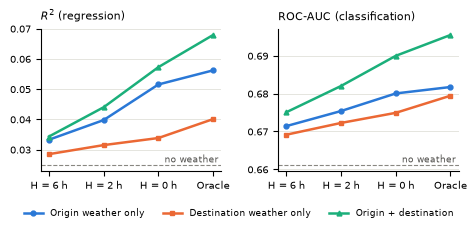

In [9]:
# Paper Fig. 4: R^2 and ROC-AUC by information setting (mean over seeds)
import matplotlib.pyplot as plt
FIG = ROOT / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
res = pd.read_csv(RESULTS / 'results_horizon.csv')
m = res[res['seed'] >= 0].groupby(['setting', 'config'])[['R2', 'AUC']].mean()
ORDER = ['H6', 'H2', 'H0', 'oracle']
XLAB = ['H = 6 h', 'H = 2 h', 'H = 0 h', 'Oracle']
STYLE = {'org': ('Origin weather only', '#2a78d6', 'o'),
         'dst': ('Destination weather only', '#eb6834', 's'),
         'both': ('Origin + destination', '#1baf7a', '^')}
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 7.5, 'pdf.fonttype': 42,
                     'axes.spines.top': False, 'axes.spines.right': False})
fig, axes = plt.subplots(1, 2, figsize=(4.8, 2.2))
for ax, metric, title in [(axes[0], 'R2', '$R^2$ (regression)'), (axes[1], 'AUC', 'ROC-AUC (classification)')]:
    for cfg, (lab, col, mk) in STYLE.items():
        ax.plot(range(4), [m.loc[(s, cfg), metric] for s in ORDER], color=col, marker=mk, ms=3.5, lw=1.8, label=lab)
    base = m.loc[('-', 'none'), metric]
    ax.axhline(base, color='#898781', ls='--', lw=0.8)
    ax.text(3.1, base, 'no weather', ha='right', va='bottom', fontsize=6.5, color='#52514e')
    ax.set_xticks(range(4)); ax.set_xticklabels(XLAB)
    ax.set_title(title, loc='left', fontsize=8)
    ax.grid(axis='y', color='#e1e0d9', lw=0.6); ax.set_axisbelow(True)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=3, frameon=False, fontsize=6.8, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.07, 1, 1))
fig.savefig(FIG / 'fig_horizon.pdf', bbox_inches='tight')
plt.show()


### Origin vs. destination: Shapley decomposition (paper Table 6)
- φ_org = ½ [(org − none) + (both − dst)]
- φ_dst = ½ [(dst − none) + (both − org)]
- interaction = both − org − dst + none (negative = redundancy, positive = synergy)

Gains are MAE reductions (positive = better) and ROC-AUC increases.

In [10]:
agg = res[res['setting'] != '-'].groupby(['setting', 'config'])[['MAE', 'AUC']].mean()
none_v = res[res['config'] == 'none'][['MAE', 'AUC']].mean()
sh = []
for setting in SETTINGS:
    v = {c: agg.loc[(setting, c)] for c in ['org', 'dst', 'both']}
    v['none'] = none_v
    for metric, sign in [('MAE', -1), ('AUC', 1)]:
        g = {c: sign * v[c][metric] for c in v}
        phi_o = 0.5 * ((g['org'] - g['none']) + (g['both'] - g['dst']))
        phi_d = 0.5 * ((g['dst'] - g['none']) + (g['both'] - g['org']))
        total = g['both'] - g['none']
        sh.append(dict(setting=setting, metric=metric, total_gain=total, phi_origin=phi_o, phi_dest=phi_d,
                       share_origin=phi_o / total if total else np.nan,
                       interaction=total - (g['org'] - g['none']) - (g['dst'] - g['none'])))
sh = pd.DataFrame(sh).round(4)
sh.to_csv(RESULTS / 'results_horizon_shapley.csv', index=False)
sh

,setting,metric,total_gain,phi_origin,phi_dest,share_origin,interaction
0,oracle,MAE,1.7261,0.9669,0.7592,0.5602,-0.1493
1,oracle,AUC,0.0342,0.0183,0.0160,0.5336,-0.0044
2,H0,MAE,1.3727,0.8149,0.5578,0.5936,-0.1372
3,H0,AUC,0.0287,0.0169,0.0118,0.5891,-0.0037
4,H2,MAE,0.9497,0.5296,0.4201,0.5576,-0.1595
5,H2,AUC,0.0208,0.0119,0.0088,0.5758,-0.0044
6,H6,MAE,0.6089,0.3082,0.3007,0.5061,-0.1297
7,H6,AUC,0.0138,0.0080,0.0058,0.5823,-0.0042


### SHAP for the deployable H2 model (supplementary)
Exploratory SHAP summary for `H2 / both`; the figures in the paper are produced by `08_shap_figures.ipynb`.

Month_cos         1.843
DepHour_sin       1.139
org_dewpt_f       1.108
Dest_te           1.050
DepTimeBlk        1.030
CRSArrHour        1.028
dst_dewpt_f       0.946
Airline_te        0.944
Tail_Number_te    0.929
Origin_te         0.795
org_temp_f        0.717
org_slp           0.697
CRSDepHour        0.682
org_thunder_3h    0.661
dst_precip_3h     0.560
DayOfWeek         0.513
OriginState       0.477
org_precip_3h     0.462
dst_humidity      0.445
Month             0.443


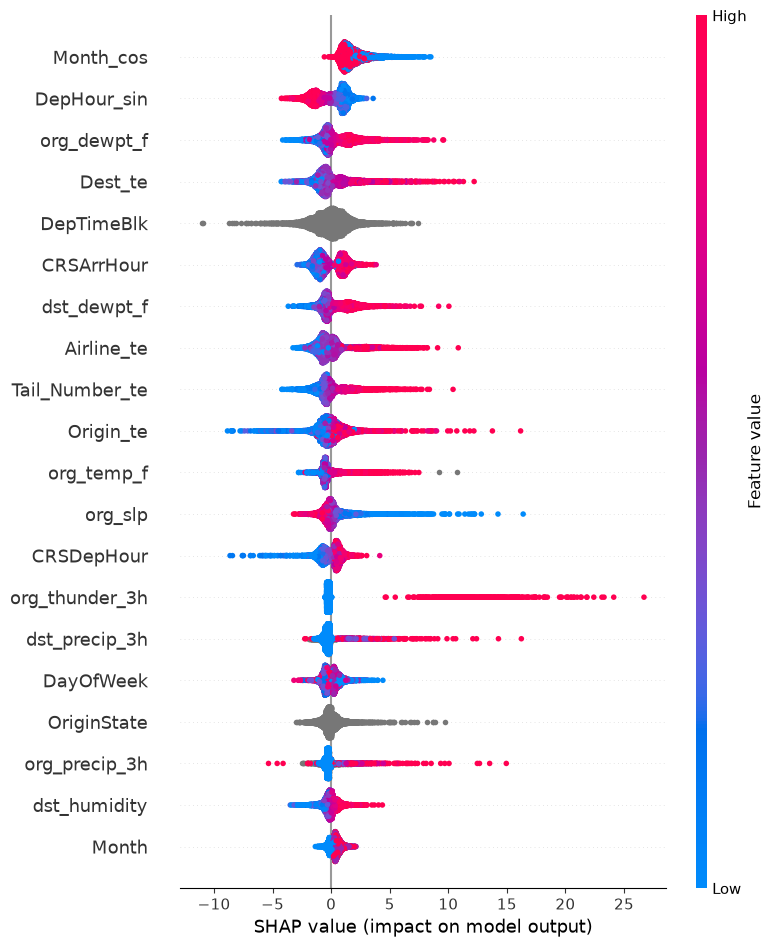

In [11]:
import shap
import matplotlib.pyplot as plt

SHAP_SETTING = 'H2' if 'H2' in models_kept else list(models_kept)[0]
model, wx_cols = models_kept[SHAP_SETTING]
W = pd.read_parquet(DATA / f'wx_{SHAP_SETTING}.parquet', columns=wx_cols)
X_te = pd.concat([X_base[te].reset_index(drop=True), W[te].reset_index(drop=True).astype('float32')], axis=1)
X_shap = X_te.sample(10000, random_state=42)
shap_values = shap.TreeExplainer(model).shap_values(X_shap)
imp = pd.Series(np.abs(shap_values).mean(0), index=X_shap.columns).sort_values(ascending=False).head(20)
print(imp.round(3).to_string())
FIG = ROOT / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.tight_layout(); plt.savefig(FIG / f'fig_shap_{SHAP_SETTING}_supplementary.pdf', bbox_inches='tight'); plt.show()